### Explanatory Data Analysis (EDA)

Imports

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid")
import os
from wordcloud import WordCloud

Raw Data

In [3]:
movies = pd.read_csv('../data/raw/movies.csv')
ratings = pd.read_csv('../data/raw/ratings.csv')
tags = pd.read_csv('../data/raw/tags.csv')
links = pd.read_csv('../data/raw/links.csv')

### Data ingestion and preprocessing

In [4]:
display(movies.head(5))

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
movies['release_year'] = movies['title'].str.extract(r'\((\d{4})\)')
movies['release_year'] = pd.to_numeric(movies['release_year'], errors='coerce')
movies['title_clean'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True).str.strip()

In [6]:
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')
tags['datetime'] = pd.to_datetime(tags['timestamp'], unit='s')

In [7]:
ratings['rating_year'] = ratings['datetime'].dt.year
ratings['rating_month'] = ratings['datetime'].dt.month

In [8]:
df = ratings.merge(movies, on='movieId', how='left')

In [9]:
missing_data = df.isnull().sum()
print("\nMissing Values per Column:")
print(missing_data[missing_data > 0])


Missing Values per Column:
release_year    18
dtype: int64


In [10]:
duplicates = df.duplicated(subset=['userId', 'movieId']).sum()
print(f"\nDuplicates Found: {duplicates}")


Duplicates Found: 0


In [11]:
print("\nProcessed Master DataFrame Preview:")
display(df[['userId', 'title_clean', 'release_year', 'rating', 'datetime']].head())


Processed Master DataFrame Preview:


,userId,title_clean,release_year,rating,datetime
0,1,Toy Story,1995.0,4.0,2000-07-30 18:45:03
1,1,Grumpier Old Men,1995.0,4.0,2000-07-30 18:20:47
2,1,Heat,1995.0,4.0,2000-07-30 18:37:04
3,1,Seven (a.k.a. Se7en),1995.0,5.0,2000-07-30 19:03:35
4,1,"Usual Suspects, The",1995.0,5.0,2000-07-30 18:48:51


In [12]:
processed_dir = '../data/processed'
df.to_parquet(f'{processed_dir}/master_data.parquet', index=False)
movies.to_parquet(f'{processed_dir}/movies_clean.parquet', index=False)
ratings.to_parquet(f'{processed_dir}/ratings_clean.parquet', index=False)

### **Univariate Analysis**

#### Rating distribution

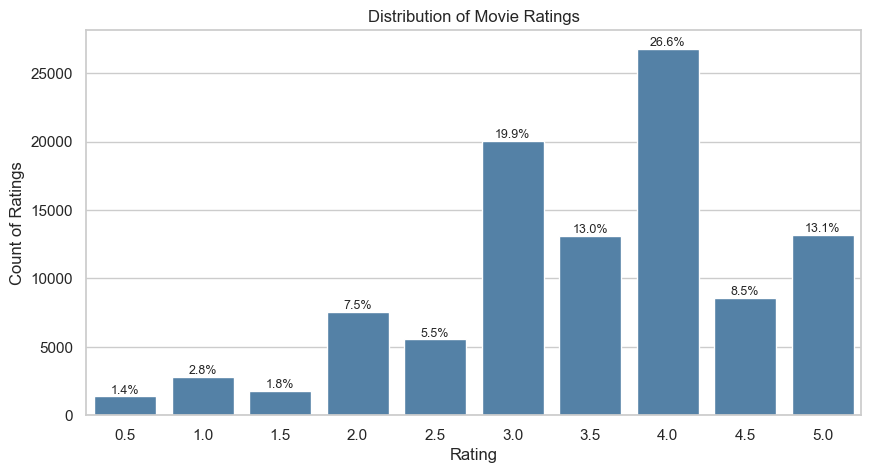

In [13]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='rating', color='steelblue')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count of Ratings')
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=9)
plt.show()

Based on the distribution of the movie ratings, we can observe several patterns
1. Postivity bias: The ratings are not normally distributed. The platform leans heavily positive, with the vast majority of ratings ($\approx 81\%$) falling at $3.0$ stars or higher. The single most common rating is $4.0$ ($26.6\%$). This suggests that users predominantly rate movies they already suspect they will enjoy, or they simply avoid finishing and rating bad movies.
2. Full-star preference: There is a clear psychological bias toward whole numbers. Users are significantly more likely to give a $3.0$, $4.0$, or $5.0$ than they are to use the half-star ratings ($2.5$, $3.5$, $4.5$).

Conclusion for futher work:
Because of the leftward skewness, an absolute rating of $3.0$ is actually considered a below-average score. If we feed raw ratings directly into a Matrix Factorization model (like SVD), it will struggle to differentiate true preferences. Therefore, before training, we must implement baseline predictors. We need to center the ratings by subtracting the global average rating, and potentially the user's specific mean rating, so the model learns deviations from the baseline rather than absolute scores.

#### Movie popularity

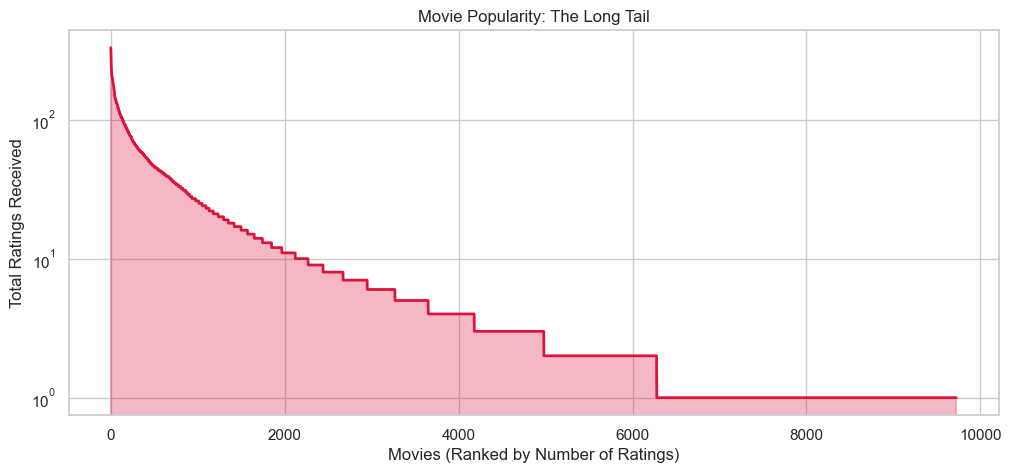

In [14]:
movie_rating_counts = df['movieId'].value_counts()
plt.figure(figsize=(12, 5))
plt.plot(movie_rating_counts.values, color='crimson', linewidth=2)
plt.fill_between(range(len(movie_rating_counts)), movie_rating_counts.values, color='crimson', alpha=0.3)
plt.title('Movie Popularity: The Long Tail')
plt.xlabel('Movies (Ranked by Number of Ratings)')
plt.ylabel('Total Ratings Received')
# Log scale helps visualize the extreme drop-off
plt.yscale('log') 
plt.show()

By observing the curve, we can identify two major groups of analyzed movies:
1. The blockbusters (the head): A small percentage of movies on the far left monopolize the majority of ratings. 
2. The niche (the long tail): As we move to the right, the curve drops off. Thousand of movies have fever than 10 ratings. The long flat line at the bottom right indicates that ma massice portion of movies in our dataset has only 1 rating.

Conclusion for further work:
We should build a Hybrid Ensemble Model rather than rely purely on Collaborative Filtering. Standard matrix factorization works well for the "head" of the curve because it has enough overlapping user data to calculate similarities. For the tail, our model has to fall back on the Content-Based Filtering, relying on data like genres, release years and tags, to find similarities based on the content of the film, rather than user behavior. 

In [15]:
print(f"Median ratings per movie: {movie_rating_counts.median()}")
print(f"Movies with < 5 ratings: {(movie_rating_counts < 5).sum()} (Cold Start Items)")

Median ratings per movie: 3.0
Movies with < 5 ratings: 6074 (Cold Start Items)


While the total number of ratings in the dataset may be high, the median number of ratings per movie is exactly 3.0. This means that fully $50\%$ of our entire movie catalog has 3 or fewer ratings. We identified exactly 6,074 movies with fewer than 5 ratings. In the context of Matrix Factorization, 5 ratings is generally considered the absolute minimum threshold required to calculate feature vectors.

#### User activity

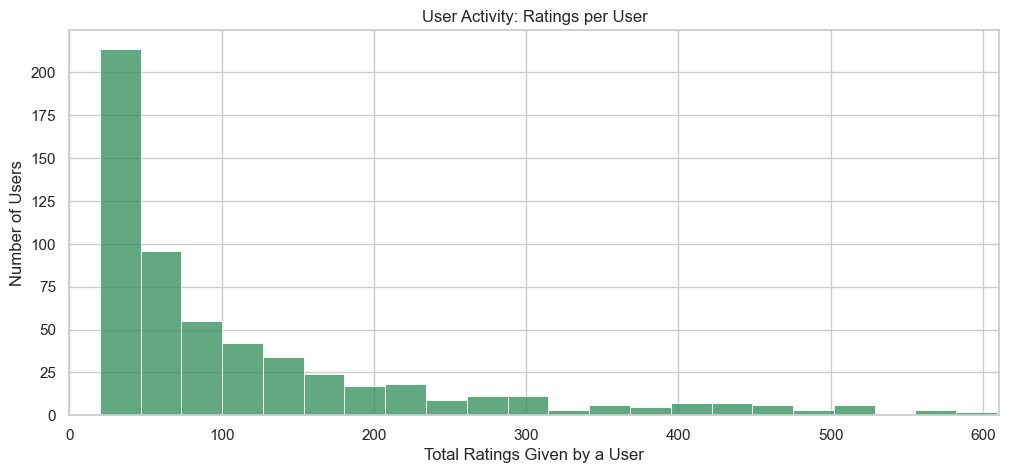

In [16]:
user_rating_counts = df['userId'].value_counts()
plt.figure(figsize=(12, 5))
sns.histplot(user_rating_counts, bins=100, color='seagreen', kde=False)
plt.title('User Activity: Ratings per User')
plt.xlabel('Total Ratings Given by a User')
plt.ylabel('Number of Users')
# Limit x-axis to zoom in on the majority of users, ignoring the extreme outliers for the plot
plt.xlim(0, user_rating_counts.quantile(0.95)) 
plt.show()

This right-skewed histogram illustrates the distribtuion of engagement across our user base. The massive spike on the far left shows that the vast majority of users are casual raters. Most users rate between 20 and 50 movies and then stop interacting with the platform. As we move to the right, the distribution trails off into a long tail of "power users." While few in number, these users have rated hundreds of movies.

Conclusion for further work:
Power users can dominate the model's training, skewing global recommendations away from the tastes of majority. To prevent this, we have to normalize the matrix by subtracting each user's average rating from their scores.

In [17]:
print(f"Median ratings per user: {user_rating_counts.median()}")
print(f"Users with < 20 ratings: {(user_rating_counts < 20).sum()} (Cold Start Users)")

Median ratings per user: 70.5
Users with < 20 ratings: 0 (Cold Start Users)


The fact that exactly 0 users have fewer than 20 ratings indicates that this dataset was pre-filtered by its creators. Every single user in our matrix has a guaranteed minimum of 20 interactions. Therefore we do not need to build a fallback mechanism for users.

#### Distribution of movie release years

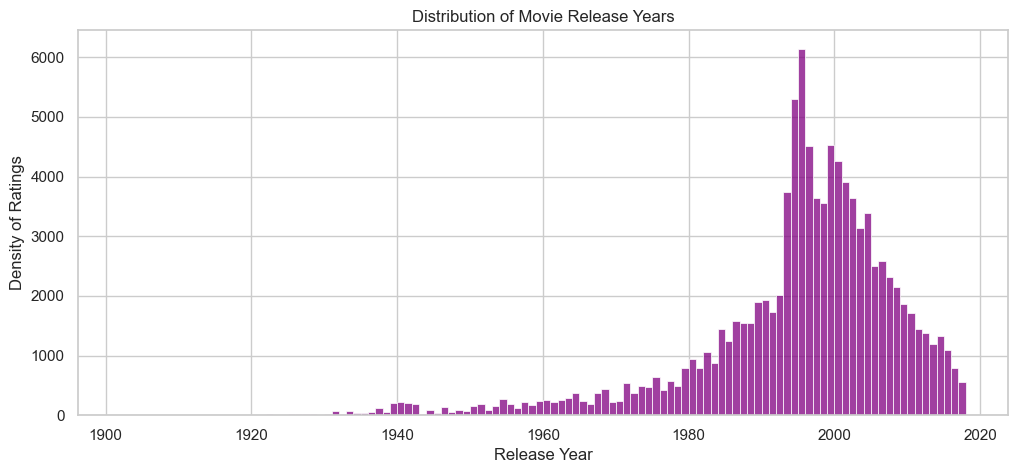

In [18]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='release_year', bins=int(df['release_year'].max() - df['release_year'].min()), color='purple')
plt.title('Distribution of Movie Release Years')
plt.xlabel('Release Year')
plt.ylabel('Density of Ratings')
plt.show()

This histogram reveals a severe chronological imbalance in our movie catalogue:
* The vast majority of user interactions are clustered around movies released between 1990 and 2010, peaking sharply around 1995.
* Movies released before 1980 receive very little overall engagement, forming a long, flat tail on the left.

Implications for our model:
Because standard CF favors items with dense interactions, the model will naturally default to recommending 90s and 2000s. We must use `release_year` as a core feature in our Content-Based pipeline. Instead of treating it as a continuous integer, we should bin these years into categorical "eras", like: "classics", "80s", "90s", "modern". This allows the embedding layer to explicitly learn if a user is a "classic film buff," helping older movies surface despite their lower overall rating volume.

### **Bivariate analysis (interactions)**

#### Movie quality vs popularity

In [19]:
movie_stats = df.groupby('title_clean').agg(
    rating_count=('rating', 'count'),
    rating_mean=('rating', 'mean')
).reset_index()
movie_stats_filtered = movie_stats[movie_stats['rating_count'] > 20]

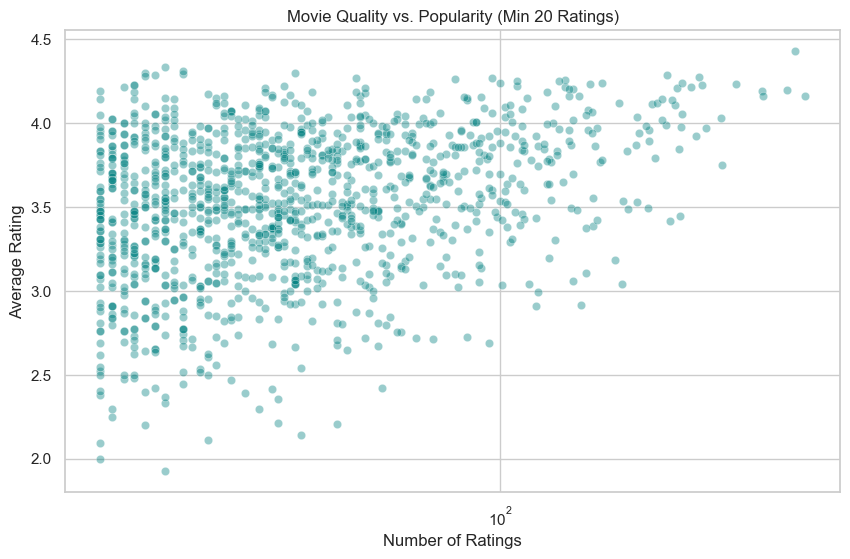

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=movie_stats_filtered, x='rating_count', y='rating_mean', alpha=0.4, color='teal')
plt.title('Movie Quality vs. Popularity (Min 20 Ratings)')
plt.xlabel('Number of Ratings')
plt.ylabel('Average Rating')
plt.xscale('log') # Log scale because of the long tail
plt.show()

This scatterplot visualizes two distinct phenomena:
1. Movies with fewer ratings (on the left) have massive variance—their averages range wildly from 2.0 to 4.5. A movie with only 20 ratings can easily be skewed by a few harsh or enthusiastic reviews.
2. As the number of ratings increases (moving right), the variance shrinks, and the average score trends upward. Highly popular movies are almost universally well-rated.

Architectural implications:
Because popular movies are highly rated, a CF model will naturally default to recommending the top-right quadrant. This creates a feedback loop where the model only recommends blockbusters. We cannot trust the raw average rating of a low-interaction movie. If we use item averages as features in our model, we must apply regularization (like Bayesian Smoothing) to pull the averages of low-count movies closer to gloval mean. Also, when we test our model later, standard accuracy metrics like RMSE will be misleadingly high if the model just guesses popular movies. We must include metrics like Coverage or Novelty to ensure the model is actually exploring the catalogue.

#### User bias

In [21]:
user_stats = df.groupby('userId').agg(
    rating_mean=('rating', 'mean'),
    rating_count=('rating', 'count')
).reset_index()

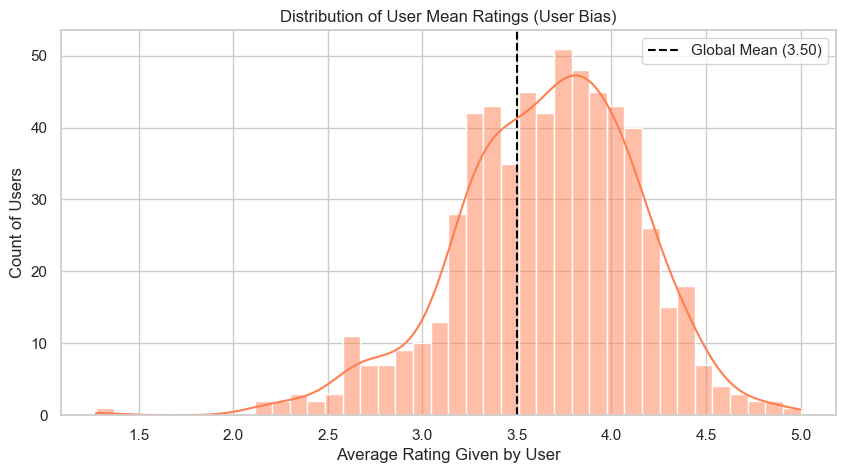

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(user_stats['rating_mean'], bins=40, color='coral', kde=True)
plt.title('Distribution of User Mean Ratings (User Bias)')
plt.xlabel('Average Rating Given by User')
plt.ylabel('Count of Users')
plt.axvline(df['rating'].mean(), color='black', linestyle='--', label=f'Global Mean ({df["rating"].mean():.2f})')
plt.legend()
plt.show()

While the global mean sits at 3.50, the peak of our distribution is actually higher (closer to 3.7 or 3.8). Furthermore, we have distinct tails: the harsh critics, who average a 2.5, and enthusiastic users, who average a 4.5.

Architectural implications:
A raw rating of 3.5 means something entirely different depending on who gave it. For a harsh critic this is a very high score, but for an enthusiastic user this means they disliked the film. This indicates the importance of normalization. By subtracting a user's personal mean from their raw ratings, we convert absolute scores into relative deviations. This ensures the model learns true preference patterns.

#### Genre performance

In [23]:
# We need to drop missing genres and explode the pipe-separated strings again
genres_df = df.dropna(subset=['genres']).copy()
genres_df['genres'] = genres_df['genres'].str.split('|')
genres_exploded = genres_df.explode('genres')

In [24]:
genre_stats = genres_exploded.groupby('genres').agg(
    rating_mean=('rating', 'mean'),
    rating_count=('rating', 'count')
).reset_index()
genre_stats = genre_stats[genre_stats['rating_count'] > 1000].sort_values('rating_mean', ascending=False)

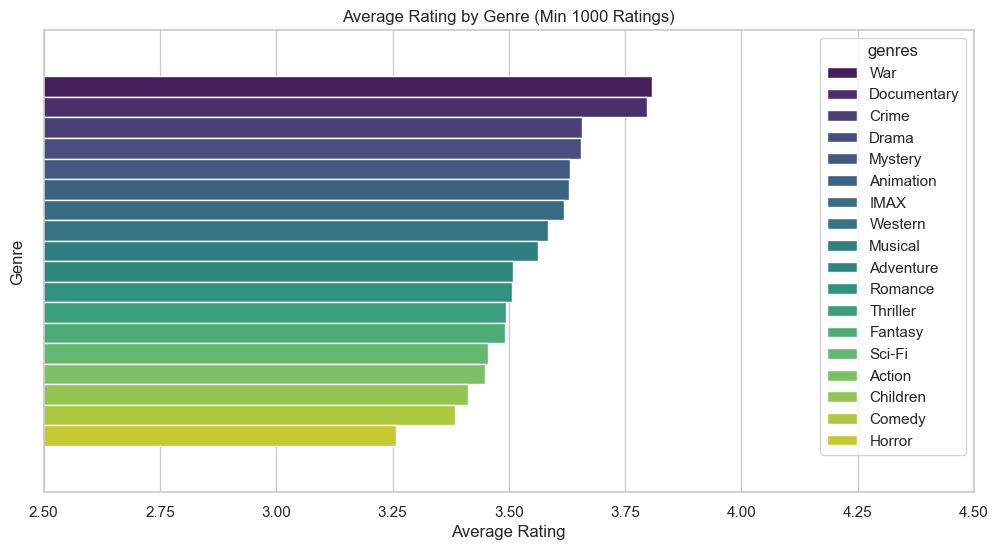

In [25]:
plt.figure(figsize=(12, 6))
sns.barplot(data=genre_stats, x='rating_mean', hue='genres', palette='viridis')
plt.title('Average Rating by Genre (Min 1000 Ratings)')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.xlim(2.5, 4.5) # Zoom in to see the differences clearly
plt.show()

* Serious, historical, or fact-based genres—specifically War and Documentary—dominate the top of the chart with averages near 3.8. Users fundamentally rate these higher, likely viewing them as "important" cinema.
* Conversely, pure entertainment genres like Comedy and Horror sit at the absolute bottom (averaging 3.25 - 3.3). A Horror fan might watch and enjoy a slasher film, but they will still rate it a 3.0 simply because of the genre's inherent stigma.

Implications for our model:
A raw score of $3.5$ means something entirely different depending on the genre. A $3.5$ is a remarkably high score for a Horror film, but a disappointingly low score for a War documentary. Because movies often span multiple genres, we must represent them using Multi-Hot Encoding. Passing these encoded genres through an embedding layer will allow the neural network to explicitly learn and neutralize these biases.

### **Temporal dynamics**

#### Platform activity over time

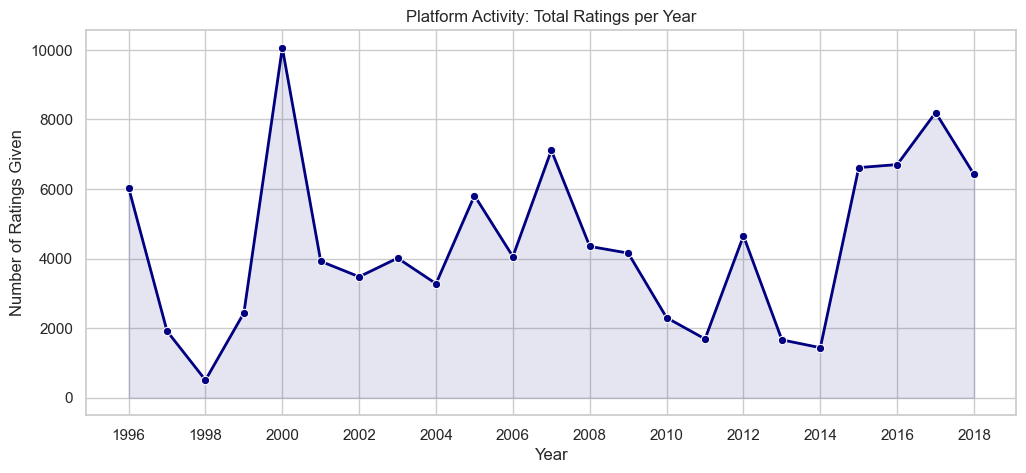

In [26]:
yearly_volume = df.groupby('rating_year').size()

plt.figure(figsize=(12, 5))
sns.lineplot(x=yearly_volume.index, y=yearly_volume.values, marker='o', color='navy', linewidth=2)
plt.fill_between(yearly_volume.index, yearly_volume.values, color='navy', alpha=0.1)
plt.title('Platform Activity: Total Ratings per Year')
plt.xlabel('Year')
plt.ylabel('Number of Ratings Given')
# Ensure x-axis shows integer years
plt.xticks(range(int(yearly_volume.index.min()), int(yearly_volume.index.max())+1, 2)) 
plt.show()

* There are massive spikes in data collection (notably around the year 2000 and again climbing towards 2018) separated by periods of very low interaction (such as 1998 and 2014).
* A model trained blindly on this entire dataset will naturally optimize for the user preferences and movie trends that were popular during that massive year-2000 spike, simply due to the volume of data.

Architectural implications:
* We cannot use a standard random 80/20 train/test split. Random splitting causes data leakage, because the model would use a user's 2018 ratings to predict their 2000 ratings, which is impossible in the real world. We must implement a Time-Based Split.
* A user's taste in 2000 is likely very different from their taste in 2018. To account for shifting preferences, we should introduce a Time Decay Function into our matrix factorization, assigning higher confidence weights to recent ratings and lower weights to older interactions.

#### Average rating over years

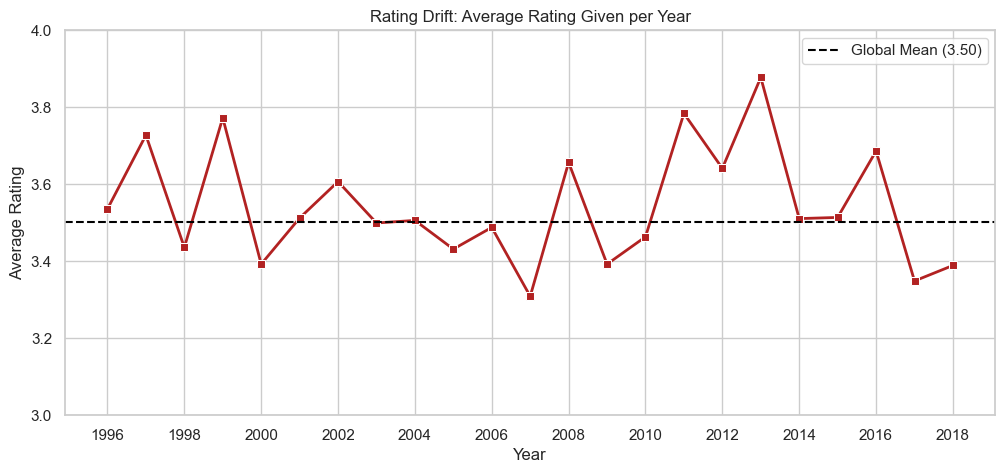

In [27]:
yearly_avg = df.groupby('rating_year')['rating'].mean()

plt.figure(figsize=(12, 5))
sns.lineplot(x=yearly_avg.index, y=yearly_avg.values, marker='s', color='firebrick', linewidth=2)
plt.title('Rating Drift: Average Rating Given per Year')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.ylim(3.0, 4.0) # Keep Y-axis tightly bounded to visualize the drift clearly
plt.axhline(df['rating'].mean(), color='black', linestyle='--', label=f'Global Mean ({df["rating"].mean():.2f})')
plt.xticks(range(int(yearly_avg.index.min()), int(yearly_avg.index.max())+1, 2))
plt.legend()
plt.show()

The year-over-year swings are observable. For instance, ratings were very generous around 1999 and 2013 (approaching 3.8 and 3.9), but a lot harsher in 2000 and 2007 (dropping down to 3.3). This volatility indicates that the psychological baseline for a "good" movie changes depending on the year.

Architectural implications:
* We can introduce a Temporal Baseline (e.g., calculating the average rating for the specific month/year the rating was given) to normalize the scores against the current mood on the platform at that exact time.

#### Day of week activity

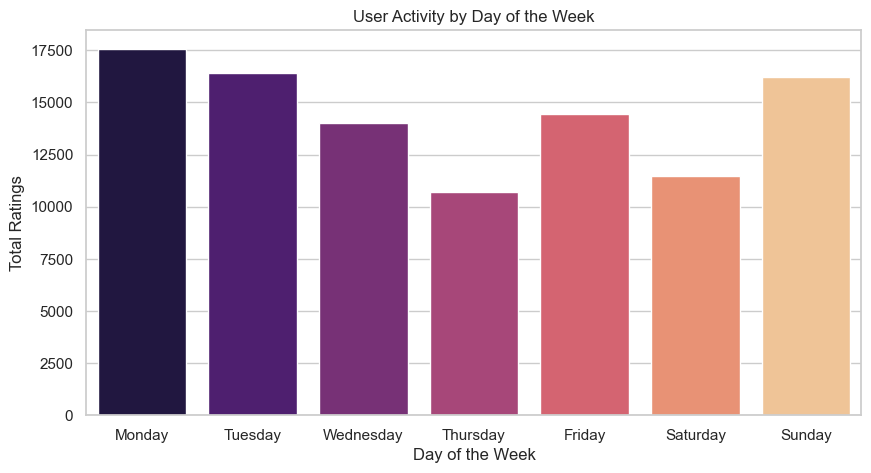

In [32]:
df['day_of_week'] = df['datetime'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_volume = df['day_of_week'].value_counts().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=day_volume.index, 
    y=day_volume.values, 
    hue=day_volume.index,
    palette='magma',
    legend=False
)
plt.title('User Activity by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Ratings')
plt.show()

This plot shows us a micro-seasonality in platorm's workflow:
* Activity is the highest at the beginning of the week and on Sundays. Monday sees the absolute peak in rating volume ($\approx 17,500$ ratings).
* Activity drops off towards the end of the workweek, hitting its lowest point on Thursday ($\approx 10,000$ ratings), with Friday and Saturday also remaining relatively low.
* This likely indicates a "logging lag." Users might watch movies over the weekend but wait until Sunday evening or Monday to actually log into the platform and rate what they watched.

Architectural implications:
Because behavior changes so drastically depending on the day, our model needs to understand when a user is asking for a recommendation. In our model pipeline we must include `day_of_week` as a categorical input feature. This will allow the embedding layers to learn day-specific habits

### **NLP & Tag Analysis**

Merging the tags with movie titles and preprocessing them by lowercasing and stripping whitespace

In [44]:
tags = tags.merge(movies[['movieId', 'title']], on='movieId', how='left')
tags['tag'] = tags['tag'].str.lower().str.strip()

print(f"Total unique tags: {tags['tag'].nunique()}")

Total unique tags: 1475


While the data is rich, 1,475 unique categorical strings present a mathematical problem. If we were to use standard One-Hot Encoding for these tags, we would add 1,475 highly sparse columns to our item matrix, exponentially increasing memory usage and computation time. Therefore, we cannot treat tags as simple categorical variables. We must use Natural Language Processing (NLP) techniques to compress this high-dimensional space.

#### Tag frequency

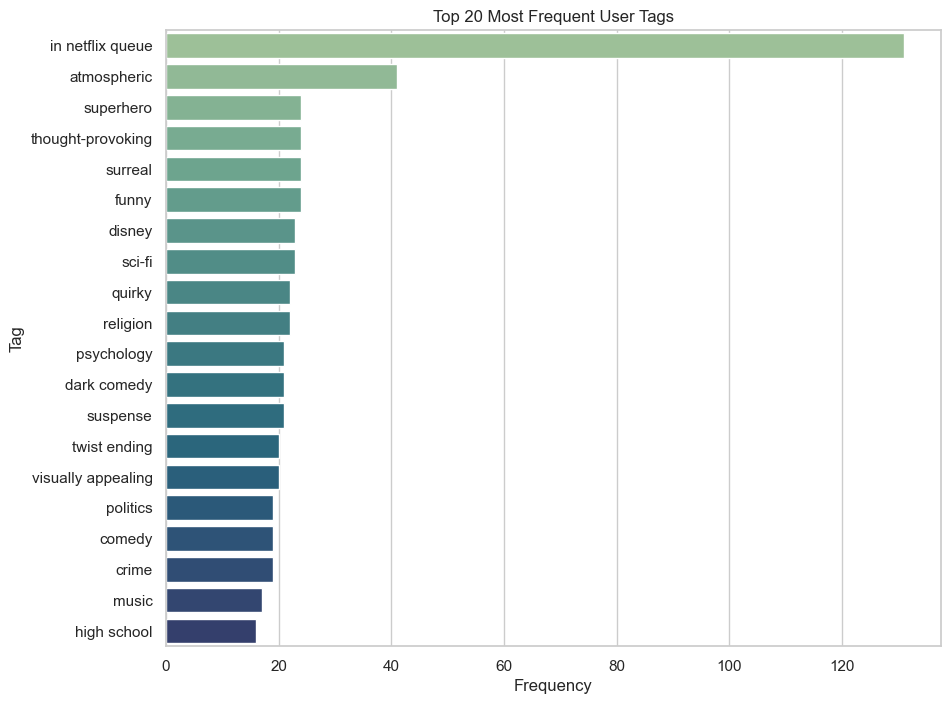

In [41]:
top_tags = tags['tag'].value_counts().head(20)

plt.figure(figsize=(10, 8))
sns.barplot(
    x=top_tags.values, 
    y=top_tags.index, 
    hue=top_tags.index, 
    palette='crest', 
    legend=False
)
plt.title('Top 20 Most Frequent User Tags')
plt.xlabel('Frequency')
plt.ylabel('Tag')
plt.show()

* The overwhelmingly dominant tag is "in netflix queue". This is a platform-specific meta-tag, not a descriptor of the movie's content. If we leave this in, our model might deduct that two completely different movies are highly similar simply because a lot of users bookmarked them to watch later.
* Below the noise, we see incredibly valuable descriptors like "atmospheric", "thought-provoking", "surreal", and "quirky". Standard genres might tell us a movie is a "Comedy", but these tags tell us if it's a quirky dark comedy versus a generic comedy.

Architectural implications:
Before we vectorize this text data, we cannot just use a standard English stop-word list. We must create a somain-specific stop-word list to filter out useless tags like: "in netflix queue", "to watch", or "owned". We might also consider TF-IDF (Term Frequency-Inverse Document Frequency) algorithm, which penalizes common tags and boost the weight of unique, highly descriptive tags.

#### Tag density per movie

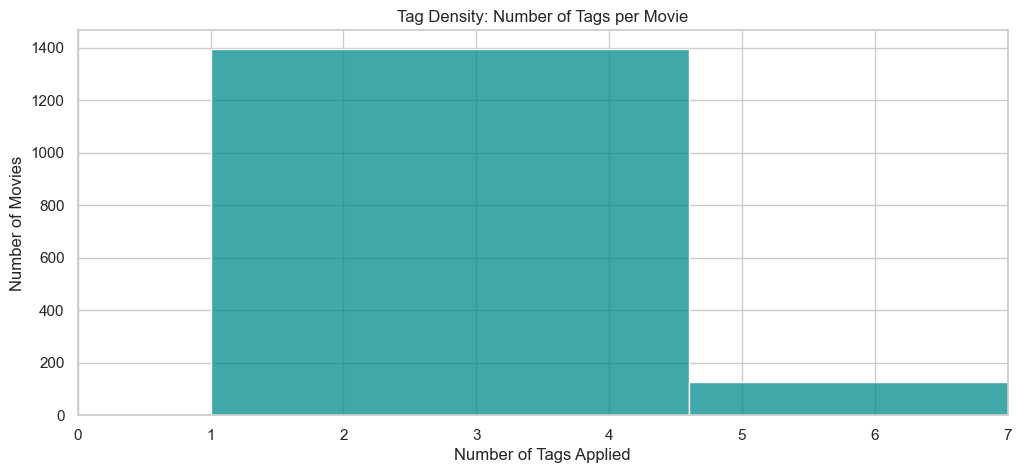

In [45]:
tag_counts_per_movie = tags.groupby('title')['tag'].count().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.histplot(tag_counts_per_movie, bins=50, color='darkcyan', kde=False)
plt.title('Tag Density: Number of Tags per Movie')
plt.xlabel('Number of Tags Applied')
plt.ylabel('Number of Movies')
plt.xlim(0, tag_counts_per_movie.quantile(0.95)) # Zoom in on the majority
plt.show()

This histogram demonstrates that while we have a large overall vocabulary, the text data per item is extremely sparse. We can observe:
* The massive block on the left shows that the vast majority of tagged movies only have between 1 and 4 tags applied to them.
* We are not dealing with movie reviews; we are dealing with ultra-short, fragmented keyword lists.

Architectural implications:
* Because a movie might only have 2 tags, standard TF-IDF might fail to match similarities if users use synonyms. Therefore, we should pass these short tag lists through a pre-trained Word Embedding Model (like Word2Vec). These models understand semantic meaning, extracting maximum value from just a handful of words.

#### Word cloud 

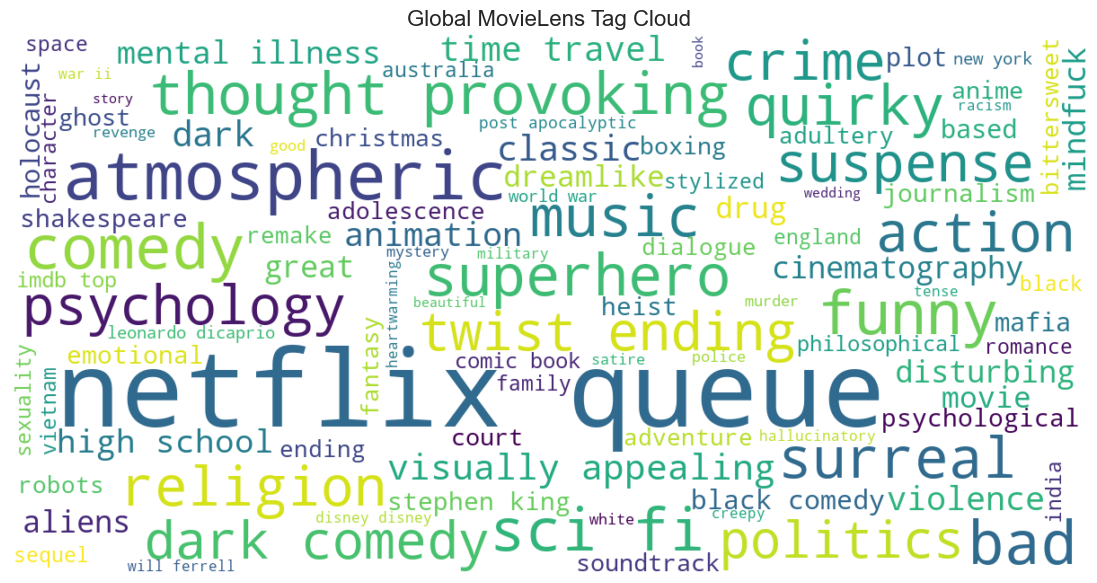

In [46]:
text = " ".join(tags['tag'].dropna().values)

wordcloud = WordCloud(
    width=1200, 
    height=600, 
    background_color='white', 
    colormap='viridis',
    max_words=100
).generate(text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Global MovieLens Tag Cloud', fontsize=16)
plt.show()

This word cloud visualizes the entire linguistic landscape of our dataset:
* As expected, "netflix queue" dominates the center, visually proving why a standard English stop-word filter isn't enough.
* Words like "atmospheric", "thought-provoking", "surreal", "mindfuck", and "visually appealing". These are highly subjective descriptors that standard genre tags (Drama or Sci-Fi) completely fail to capture.
* We also see highly specific sub-genres ("time travel", "heist", "post apocalyptic") and specific entities ("stephen king", "leonardo dicaprio").

### **Sparsity and cold start evaluation**

#### Global matrix sparsity

In [47]:
num_users = df['userId'].nunique()
num_movies = df['movieId'].nunique()
num_ratings = len(df)

total_possible_interactions = num_users * num_movies
sparsity = (1 - (num_ratings / total_possible_interactions)) * 100

In [48]:
print(f"Total Users: {num_users}")
print(f"Total Movies: {num_movies}")
print(f"Total Ratings: {num_ratings}")
print(f"Global Matrix Sparsity: {sparsity:.2f}%")

Total Users: 610
Total Movies: 9724
Total Ratings: 100836
Global Matrix Sparsity: 98.30%


Our final EDA metrics confirm that the user-item interaction matrix is 98.30% sparse. Out of nearly 6 million possible combinations, we only have roughly 100,000 recorded interactions. Furthermore, the next plot visually proves that a massive percentage of our catalog belongs to the "extreme cold" side.

#### Cold start problem

In [51]:
item_counts = df.groupby('movieId').size()
bins = [0, 1, 5, 10, 50, 100, np.inf]
labels = ['1 Rating (Extreme Cold)', '2-5 Ratings (Cold)', '6-10 Ratings (Warm)', 
          '11-50 Ratings (Standard)', '51-100 Ratings (Popular)', '100+ Ratings (Blockbuster)']
cold_start_distribution = pd.cut(item_counts, bins=bins, labels=labels).value_counts().reindex(labels)

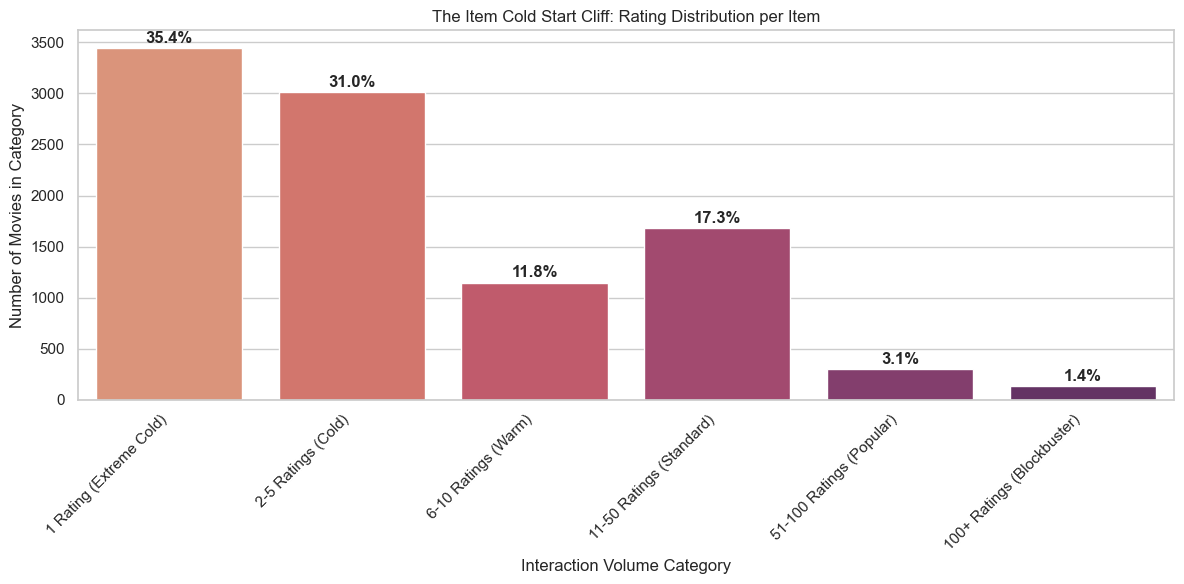

In [52]:
plt.figure(figsize=(12, 6))
sns.barplot(x=cold_start_distribution.index, y=cold_start_distribution.values, 
            hue=cold_start_distribution.index, palette='flare', legend=False)
plt.title('The Item Cold Start Cliff: Rating Distribution per Item')
plt.xlabel('Interaction Volume Category')
plt.ylabel('Number of Movies in Category')
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(cold_start_distribution.values):
    percentage = (v / num_movies) * 100
    plt.text(i, v + 50, f'{percentage:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

* 66.4% of our entire movie catalog (35.4% + 31.0%) has 5 or fewer ratings. Standard matrix factorization algorithms cannot mathematically find patterns with so little data
* Only roughly 20% of our catalog sits in the "Standard" to "Blockbuster" tiers (11+ ratings). These are the movies that generate the majority of our overall traffic and will dominate standard model training.

#### **Final conclusion**

To build a reliable recommendation system we must implement a two-pipeline hybrid model:
1. Pipeline A (Collaborative filtering): For the ~22% of the catalog on the right side, we will use Deep Neural Collaborative Filtering. This pipeline will map dense user behavior.
2. Pipeline B (Content-Based NLP): For the ~78% of the catalog on the left side, we will dynamically route predictions through a Content-Based engine. This pipeline will use the Multi-Hot encoded genres and dense Word2Vec tag embeddings we engineered in Phases 3 and 5 to calculate item similarity based purely on metadata.